## Hyperparameter tuning protype

Goal: Tune the parameters of the baseline machine learning model to produce the best RMSE

Parameters:
- **Learning Rate**: 1e-5 to 1e-1
- **Batch Size**: [16, 32, 64, 128]
- **Filters**:
        [16, 32, 32],
        [32, 64, 64],
        [64, 128, 128]
- **Optmizer**: ["Adam", "AdamW", "RMSProp"]
- **Weight Decay**: 1e-6 to 1e-2

Procedure:
1. Randomly select 20 configurations to test from the selected options
2. Train for 20 epochs, record the validation loss for each run
3. Select the 5 best performing models
4. Train the 5 best configurations for 50 epochs
5. Test using the testing data by doing a "forecast_rollout" and compare the global RMSE
6. Select the best perfoming model

In [1]:
import optuna
from utils.utils import VarSet, DataSet
from architectures.cnn_baseline import CNN2D, set_seed, Results

def objective(trial, data, nepochs, label):
    filter_options = [
        [16, 32, 32],
        [32, 64, 64],
        [64, 128, 128]
    ]

    config = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64, 128]),
        "filters": trial.suggest_categorical("filters", filter_options),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSProp"]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    }

    model = CNN2D(
        data,
        num_epochs=nepochs,
        batch_size=config["batch_size"],
        lr=config["learning_rate"],
        filters=config["filters"],
        weight_decay=config["weight_decay"],
        optimizer=config["optimizer"],
        case=4,
        label=f"run_{label}_trial_{trial.number:02d}",
        debug=False
    )
    
    model.train()

    return model.get_val_loss("t_ref")

def run_optuna_study(data, nepochs=20, n_trials=20, label=""):
    study = optuna.create_study(direction="minimize", storage="sqlite:///optuna_study.db",
                                load_if_exists=True,
                                sampler=optuna.samplers.TPESampler(seed=42))
    
    study.optimize(lambda trial: objective(trial, data, nepochs, label), n_trials=n_trials)

    print("Best trial:")
    print(f"  Value: {study.best_value}")
    print(f"  Params: {study.best_params}")
    
    return study.trials_dataframe()

/work/unr/SPEAR_EMULATOR/wut/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
set_seed()
from utils.utils import VarSet, DataSet
from architectures.cnn_baseline import CNN2D, set_seed, Results

set_seed()
t_ref = VarSet(
    var_name="t_ref",
    file_name="PP_DATA/t_ref.192101-201012.nc",
    is_output=True
)

spatial_features = VarSet(
    var_name="spatial_features",
    file_name="PP_DATA/spatial_features.nc",
    is_static=True
)

variables = [t_ref, spatial_features]
data = DataSet(set_name="set1", variables=variables)
lon, lat = t_ref.get_grid()
time_test = t_ref.get_time('time_test')

wut = run_optuna_study(data, nepochs=20, n_trials=20, label="optuna")


[I 2026-02-18 08:59:14,324] A new study created in RDB with name: no-name-f0f9dfe3-3f15-4017-8f70-7fbcec04e849
/work/unr/SPEAR_EMULATOR/wut/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [16, 32, 32] which is of type list.
  optuna_warn(message)
/work/unr/SPEAR_EMULATOR/wut/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [32, 64, 64] which is of type list.
  optuna_warn(message)
/work/unr/SPEAR_EMULATOR/wut/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [64, 128, 128] which is of type list.
  optuna_warn(message)
[I 2026-02-18 08:59:15,096] T

Best trial:
  Value: 0.009567503371618243
  Params: {'learning_rate': 0.0004395333516766407, 'batch_size': 32, 'filters': [64, 128, 128], 'optimizer': 'AdamW', 'weight_decay': 5.475291926781571e-06}


In [15]:
sorted_df = wut.sort_values(by="value", ascending=True)
best_configurations = sorted_df.iloc[0:5]
print(best_configurations)

    number     value             datetime_start          datetime_complete  \
17      17  0.009568 2026-02-18 08:59:22.539892 2026-02-18 08:59:22.956162   
5        5  0.009984 2026-02-18 08:59:16.856880 2026-02-18 08:59:17.368388   
16      16  0.010310 2026-02-18 08:59:22.092166 2026-02-18 08:59:22.476397   
3        3  0.010437 2026-02-18 08:59:15.952241 2026-02-18 08:59:16.347534   
4        4  0.012750 2026-02-18 08:59:16.417197 2026-02-18 08:59:16.797259   

                 duration  params_batch_size  params_filters  \
17 0 days 00:00:00.416270                 32  [64, 128, 128]   
5  0 days 00:00:00.511508                 32  [64, 128, 128]   
16 0 days 00:00:00.384231                 32  [64, 128, 128]   
3  0 days 00:00:00.395293                 32  [64, 128, 128]   
4  0 days 00:00:00.380062                 32  [64, 128, 128]   

    params_learning_rate params_optimizer  params_weight_decay     state  
17              0.000440            AdamW             0.000005  COMPLET

In [16]:
Model_results = Results(lon, lat)

nepochs = 50
for id, configuration in best_configurations.iterrows():
    batch_size = int(configuration["params_batch_size"])
    filters = configuration["params_filters"]
    learning_rate = configuration["params_learning_rate"]
    optimizer = configuration["params_optimizer"]
    weight_decay = configuration["params_weight_decay"]

    Model = CNN2D(data,
              num_epochs=nepochs,
              batch_size=batch_size,
              lr = learning_rate,
              filters = filters,
              weight_decay = weight_decay,
              optimizer=optimizer,
              case = 4,
              label = f"EncoderDecoderOptimize.{id:02d}",
              debug = True)


    Model.train()
    Model_results.add_model_output(Model, run_type="forecast_rollout")

Model3 = CNN2D(data, case=2, label="baseline_batchnorm_sampling")
Model3.train()
Model_results.add_model_output(Model3, run_type="forecast_rollout")


EncoderDecoderOptimize.17 - Sequential(
  (0): Conv2d(7, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ReLU(inplace=True)
  (9): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (11): ReLU(inplace=True)
  (12): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplace=True)


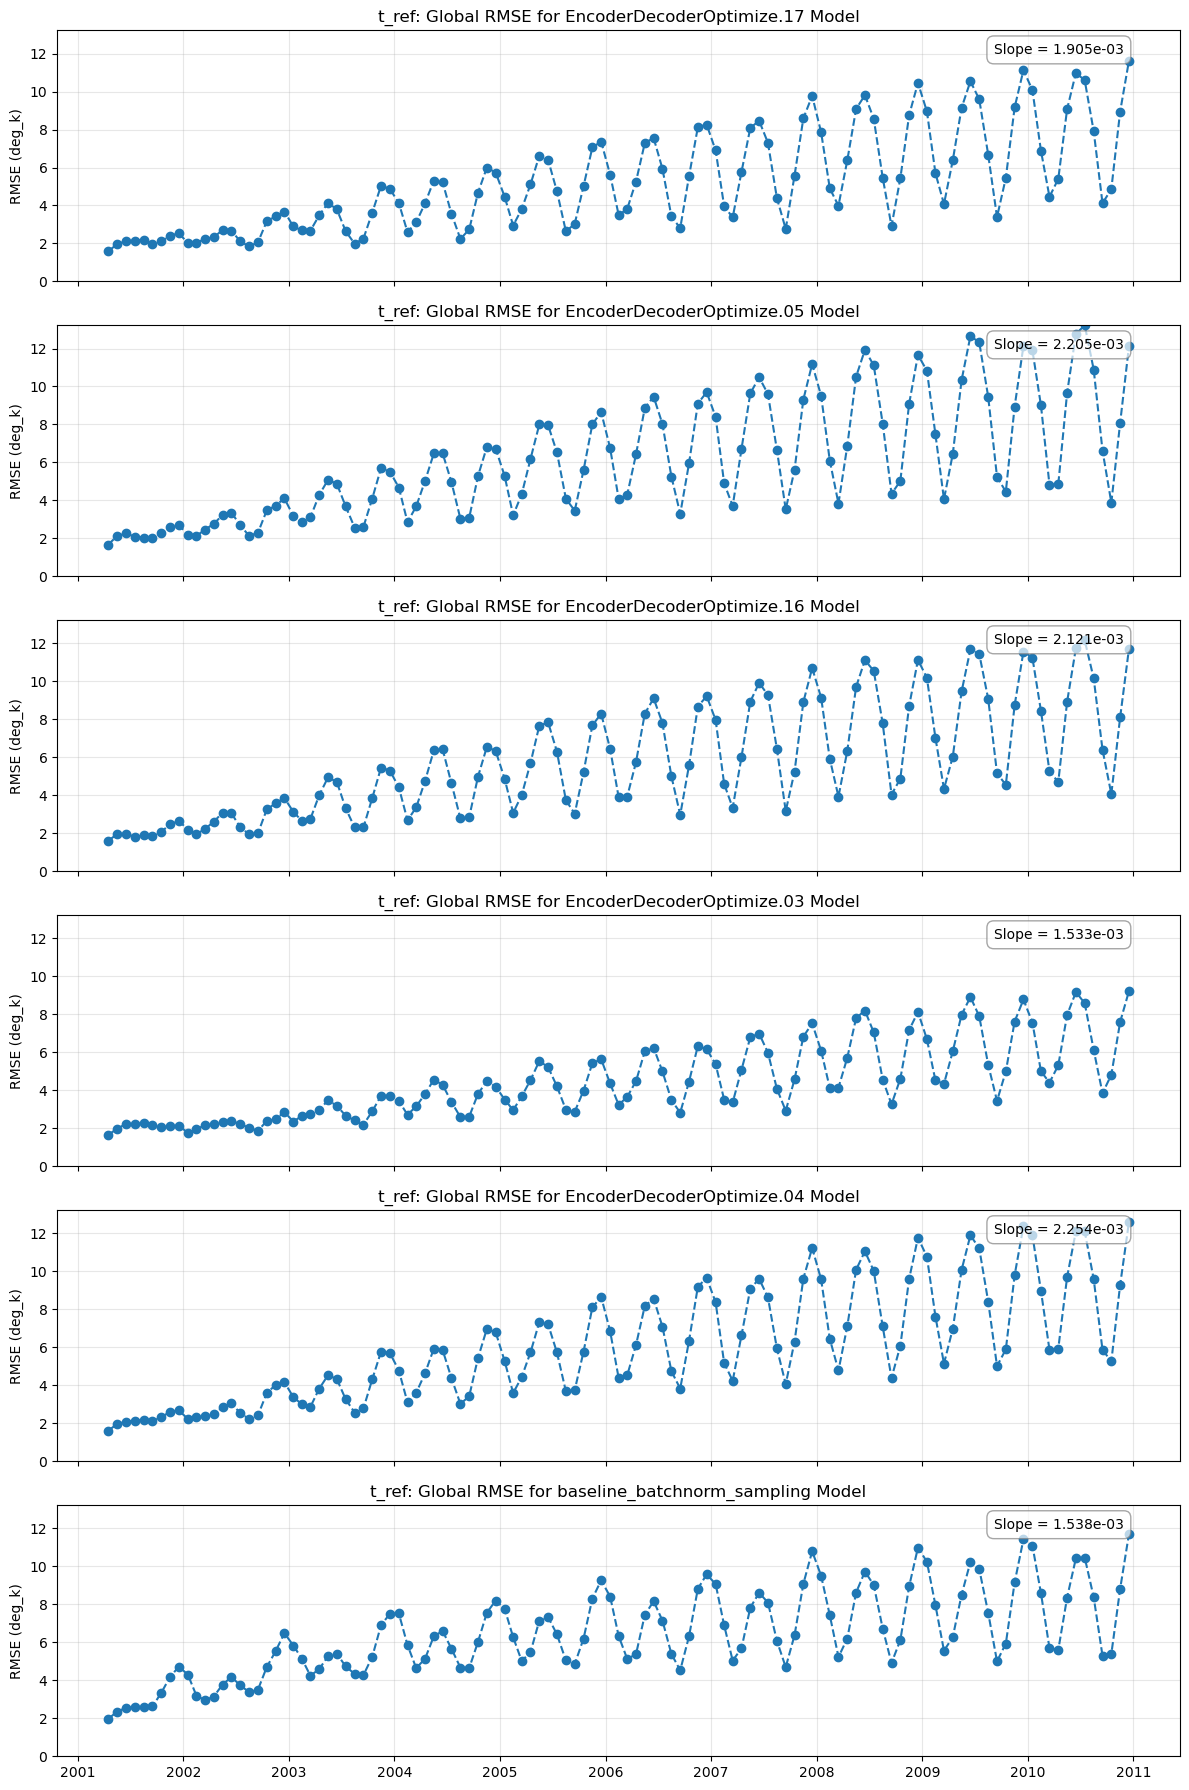

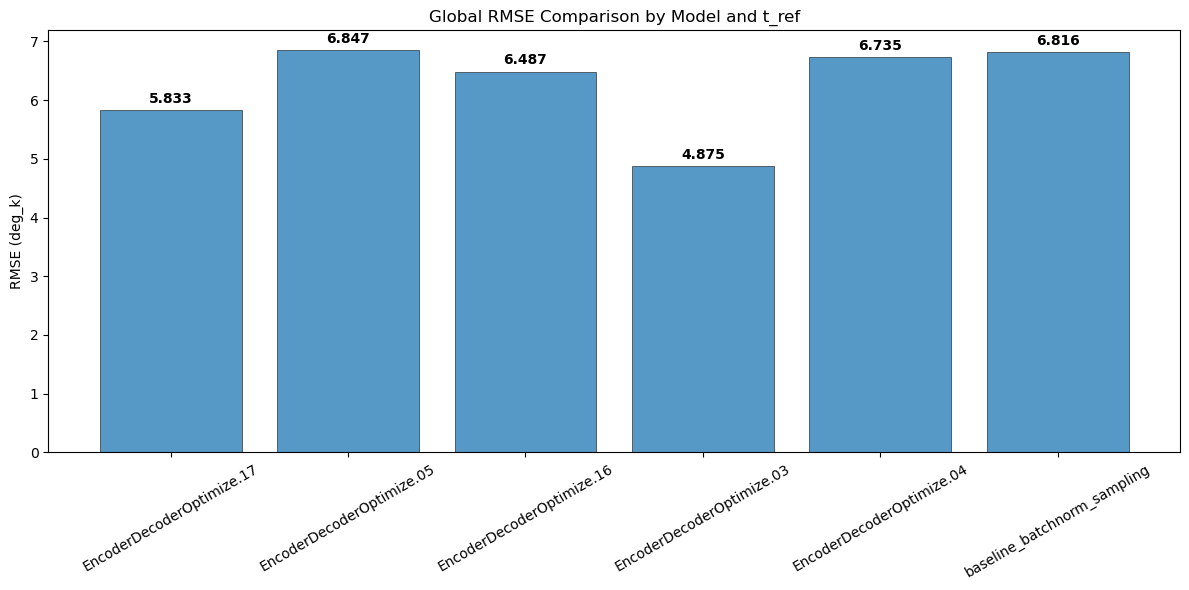

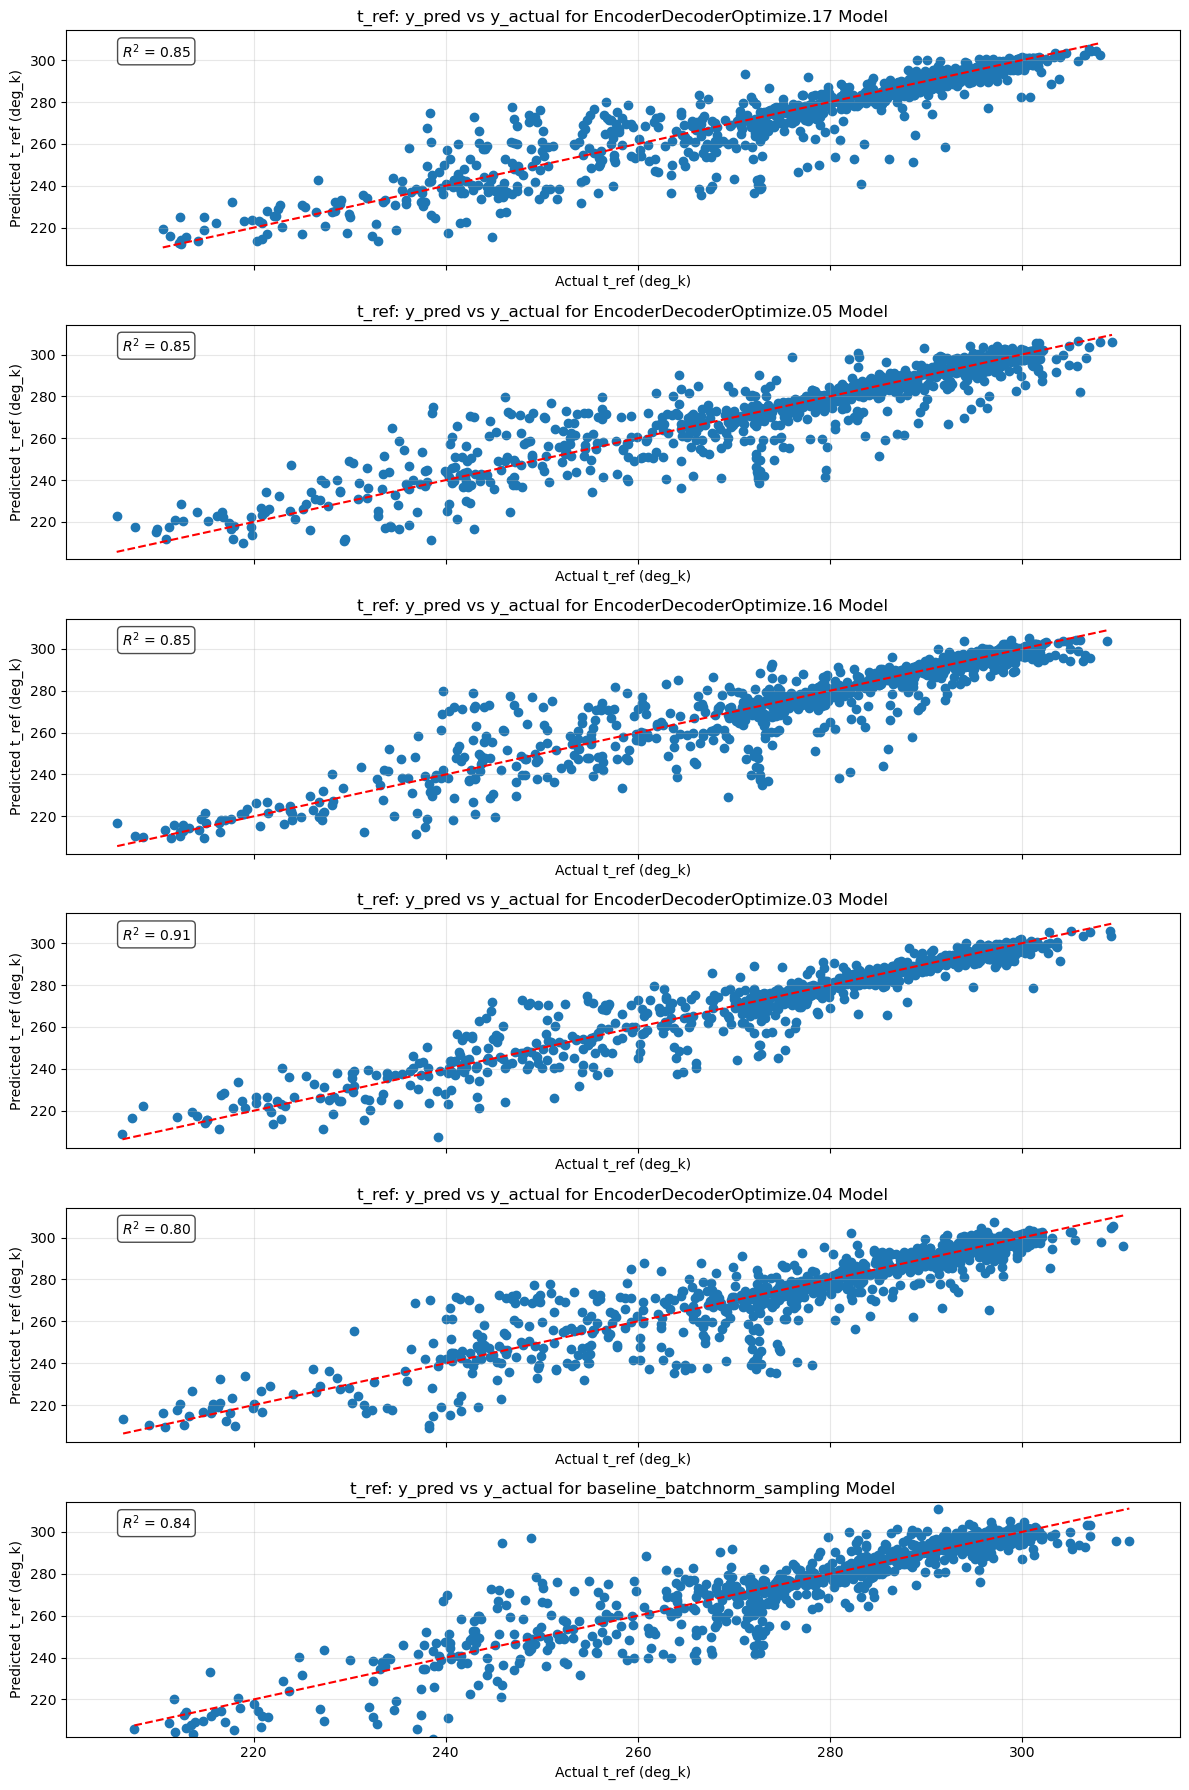

In [18]:
Model_results.plot_temporal_RMSE('t_ref', time_test)
Model_results.plot_global_RMSE('t_ref')
Model_results.plot_scatter_y_pred_vs_y_actual("t_ref")

In [ ]:
# This was chosen manually by looking at the plots above
target_id = 3

best_run = best_configurations[best_configurations['number'] == target_id]
best_run = best_run.iloc[0]

print(f"Summary of best performing configuration:")
print(f"-> Learning Rate: {best_run['params_learning_rate']}")
print(f"-> Layers: {best_run['params_filters']}")
print(f"-> Batch Size: {best_run['params_batch_size']}")
print(f"-> Optimizer: {best_run['params_optimizer']}")
print(f"-> Weight Decay: {best_run['params_weight_decay']}")

Summary of best performing configuration:
-> Learning Rate: 0.00016536937182824412
-> Layers: [64, 128, 128]
-> Batch Size: 32
-> Optimizer: AdamW
-> Weight Decay: 0.00012030178871154674
